In [137]:
# import modules
import os
import sys
import matplotlib

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
from scipy.stats import ttest_rel, pearsonr, t
from scipy.stats import norm
from ast import literal_eval
import pingouin as pg

from statistical_tests import (
    check_normality,
    cohens_d_ci,
    mean_diff_ci,
    eta_squared_ci,
    cousineau_morey_ci,
    paired_ttest_analysis,
    onesample_ttest_analysis,
    rm_anova_analysis
)

data_folder = '//Users/dockduncan/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/Online_Results/gilles_pilot/'
download_folder = '//Users/dockduncan/Downloads/'

current_folder = os.getcwd()

In [138]:
# set plotting parameters
# inspired by http://nipunbatra.github.io/2014/08/latexify/
params = {
    'axes.labelsize': 12, # fontsize for x and y labels (was 10)
    'axes.titlesize': 12,
    'font.size': 10, # was 10
    'legend.fontsize': 10, # was 10
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.family': 'optima',
}
matplotlib.rcParams.update(params)

meanlineprops = dict(linestyle='--', linewidth=1, color='black')
medianlineprops = dict(linestyle=None, linewidth=0, color='black')

pd.set_option('display.max_columns', None)


In [139]:
# read in data

df = pd.read_excel(data_folder + 'data1.xlsx' ) # here i load in the datafile. data_folder is the folder on my computer where the file is located

df['age'] = df['response_age_10']*10 + df['response_age_01']

columns_oi = ['PROLIFIC_PID','agg_points','bar1','bar2','barloc','block','block_trial','condition',
              'correct', 'correct_response','dist_col','feedback','high_val_col',
              'iti1','iti2','jatosStudyResultId','loc_dist','loc_tar','low_val_col',
              'participantId','practice','response', 'response_age_01','response_age_10','response_gender',
              'response_time','sessionid','target_dot','trial_nr','trial_points']
df = df[columns_oi]

df = df.rename(columns={'response_time': 'RT',
                    #    'trial_shape': 'distractor_id',
                    #    'response_color_response': 'selected_color',
                       'participantId': 'id',
                    #    'count_block_loop':'block'
                       })


df['logRT'] = np.log(df.RT)

# # Map distractor image filenames to human-friendly names and apply
# image_to_name = {
#     'foodstim-01.png': 'apples',
#     'foodstim-02.png': 'grapes',
#     'foodstim-03.png': 'oranges',
#     'foodstim-04.png': 'cheese',
#     'foodstim-05.png': 'hotdogs',
#     'foodstim-06.png': 'sushi',
#     'foodstim-07.png': 'corn',
#     'foodstim-08.png': 'avocados',
#     'foodstim-09.png': 'peppers',
#     'foodstim-10.png': 'cookies',
#     'foodstim-11.png': 'croissants',
#     'foodstim-12.png': 'cupcakes',
# }

# # Clean and replace in-place; keep original value when no mapping exists
# if 'distractor_id' in df.columns:
#     df['distractor_id'] = df['distractor_id'].astype(str).str.strip()
#     df['distractor_id'] = df['distractor_id'].map(lambda x: image_to_name.get(x, x))
# else:
#     print("Column 'distractor_id' not found; please verify the rename step earlier.")

# Optional: also store the mapped names in a separate column
# df['distractor_name'] = df['distractor_id'].map(lambda x: image_to_name.get(x, x))

# Sanity check
# print('Unique distractor labels:', sorted(pd.unique(df['distractor_id'])))

# # df['trial_nr'] = df.groupby('subject_nr')['trial_nr'].transform(lambda x: x - (x.min() - 1))
df['dist'] =  np.where(df['dist_col'] == 99, 'nd',
            np.where(df['dist_col'] > 4, 'low','hi'))

In [140]:
# get overview of subjects
pivot = df.pivot_table(index = 'id', values = 'RT', aggfunc='count')
all_sjs = pivot.index
print('Data set contains {} subjects, with the following IDs {}'.format(all_sjs.size, np.sort(all_sjs)))

Data set contains 28 subjects, with the following IDs ['5aad4225811b2000016f6ed1' '5d9e3ec9611b0b0017b14b9a'
 '5dd05d80b2204f1487f7812c' '5e611f10a40777000bb4f2e5'
 '5ea9a6a68db51d0dfd2edfe2' '5f01b7e94738d231487f2911'
 '5f70f2daea9a9f7076484982' '606cf604adbb6982bb382881'
 '60fef19b9c12d84b5a87fa1d' '64c9892e8e7e06812b775c0c'
 '65e47142265c50fcd9e87278' '65e5d51b9a403c3bd5fe0b07'
 '66bb28d7c5549cce9b8c2d07' '66c49547930d772bd1c165af'
 '66ceb0af1cd3e27b364bfd53' '671e39c25e5e3f340a6f21d4'
 '672fabf000e147eef4790d45' '67cef9b91dd192c0b3728e12'
 '681b781064a5701a5ceee3bc' '6824fd5f12b792fdaec9b2be'
 '695d3358e279e99f97eef93e' '695d6323922e5b6f33345f2b'
 '696d341fcf5b125d9f7960ba' '6977a95b9c55f6dd316d674f'
 '6978c747e184ed4d0341f8a2' '697bb985666353a18b2a8fa5'
 '698209da929c41a283d2103a' '698725ce979bc4d4ea7c7373']


In [141]:

df

,PROLIFIC_PID,agg_points,bar1,bar2,barloc,block,block_trial,condition,correct,correct_response,dist_col,feedback,high_val_col,iti1,iti2,jatosStudyResultId,loc_dist,loc_tar,low_val_col,id,practice,response,response_age_01,response_age_10,response_gender,RT,sessionid,target_dot,trial_nr,trial_points,logRT,dist
0,64c9892e8e7e06812b775c0c,0,1,0,-125,-1,1,1,0,a,4,1,orange,1883,1098,499,7,3,green,64c9892e8e7e06812b775c0c,1,NaN,0,5,f,1765,1771158766003,0,1,0,7.475906,hi
1,64c9892e8e7e06812b775c0c,0,1,0,-75,-1,2,1,0,s,6,1,orange,1475,1099,499,3,5,green,64c9892e8e7e06812b775c0c,1,NaN,0,5,f,1756,1771158766003,1,2,0,7.470794,low
2,64c9892e8e7e06812b775c0c,810,1,0,-25,-1,3,1,1,a,4,1,orange,1496,1224,499,5,3,green,64c9892e8e7e06812b775c0c,1,a,0,5,f,940,1771158766003,0,3,810,6.845880,hi
3,64c9892e8e7e06812b775c0c,810,1,0,25,-1,4,1,0,s,1,1,orange,1189,1037,499,5,7,green,64c9892e8e7e06812b775c0c,1,NaN,0,5,f,1761,1771158766003,1,4,0,7.473637,hi
4,64c9892e8e7e06812b775c0c,810,1,0,75,-1,5,1,0,s,0,1,orange,1294,1183,499,9,7,green,64c9892e8e7e06812b775c0c,1,NaN,0,5,f,1765,1771158766003,1,5,0,7.475906,hi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11458,6978c747e184ed4d0341f8a2,168705,1,0,75,9,453,1,1,a,6,1,orange,1746,1338,474,5,1,green,6978c747e184ed4d0341f8a2,0,a,2,2,f,684,1771150373762,0,453,107,6.527958,low
11459,6978c747e184ed4d0341f8a2,168766,1,0,125,9,454,1,1,s,9,1,orange,1359,1024,474,1,7,green,6978c747e184ed4d0341f8a2,0,s,2,2,f,1141,1771150373762,1,454,61,7.039660,low
11460,6978c747e184ed4d0341f8a2,168867,1,0,175,9,455,1,1,s,99,0,orange,1663,1663,474,9,3,green,6978c747e184ed4d0341f8a2,0,s,2,2,f,741,1771150373762,1,455,101,6.608001,nd
11461,6978c747e184ed4d0341f8a2,169787,0,1,-175,9,456,1,1,a,4,0,orange,1995,1935,474,1,5,green,6978c747e184ed4d0341f8a2,0,a,2,2,f,833,1771150373762,0,456,920,6.725034,hi


In [142]:
# # get rid of subjects with incomplete datasets
pivot = df.pivot_table(index = 'id', values = 'RT', aggfunc='count')
complete = pivot.index[np.squeeze(pivot > 400)]
df = df[df.id.isin(complete)]
print(complete.shape)
pivot

(23,)


,RT
id,
5aad4225811b2000016f6ed1,457
5d9e3ec9611b0b0017b14b9a,457
5dd05d80b2204f1487f7812c,523
5e611f10a40777000bb4f2e5,32
5ea9a6a68db51d0dfd2edfe2,479
5f01b7e94738d231487f2911,457
5f70f2daea9a9f7076484982,457
606cf604adbb6982bb382881,479
60fef19b9c12d84b5a87fa1d,457


In [143]:
# get rid of subjects with accuracy <  50%
pivot = df.pivot_table(index = 'id', values = 'correct', aggfunc='mean')
complete = pivot.index[np.squeeze(pivot > 0.60)]
# pivot = df.pivot_table(index = 'subject_nr', values = 'correct', aggfunc='mean')
fail = df[~df.id.isin(complete)].pivot_table(index = 'id', values = 'correct', aggfunc='mean')
print(fail)
print(len(fail))
df = df[df.id.isin(complete)]
print(complete.shape)
pivot

Empty DataFrame
Columns: []
Index: []
0
(23,)


,correct
id,
5aad4225811b2000016f6ed1,0.892779
5d9e3ec9611b0b0017b14b9a,0.890591
5dd05d80b2204f1487f7812c,0.869981
5ea9a6a68db51d0dfd2edfe2,0.914405
5f01b7e94738d231487f2911,0.943107
5f70f2daea9a9f7076484982,0.892779
606cf604adbb6982bb382881,0.889353
60fef19b9c12d84b5a87fa1d,0.932166
64c9892e8e7e06812b775c0c,0.835073


In [144]:
df.pivot_table(index = 'id', values = 'agg_points', aggfunc='max')

,agg_points
id,
5aad4225811b2000016f6ed1,178204
5d9e3ec9611b0b0017b14b9a,154650
5dd05d80b2204f1487f7812c,132667
5ea9a6a68db51d0dfd2edfe2,135426
5f01b7e94738d231487f2911,166823
5f70f2daea9a9f7076484982,151834
606cf604adbb6982bb382881,114982
60fef19b9c12d84b5a87fa1d,167736
64c9892e8e7e06812b775c0c,117128


In [145]:
df

,PROLIFIC_PID,agg_points,bar1,bar2,barloc,block,block_trial,condition,correct,correct_response,dist_col,feedback,high_val_col,iti1,iti2,jatosStudyResultId,loc_dist,loc_tar,low_val_col,id,practice,response,response_age_01,response_age_10,response_gender,RT,sessionid,target_dot,trial_nr,trial_points,logRT,dist
0,64c9892e8e7e06812b775c0c,0,1,0,-125,-1,1,1,0,a,4,1,orange,1883,1098,499,7,3,green,64c9892e8e7e06812b775c0c,1,NaN,0,5,f,1765,1771158766003,0,1,0,7.475906,hi
1,64c9892e8e7e06812b775c0c,0,1,0,-75,-1,2,1,0,s,6,1,orange,1475,1099,499,3,5,green,64c9892e8e7e06812b775c0c,1,NaN,0,5,f,1756,1771158766003,1,2,0,7.470794,low
2,64c9892e8e7e06812b775c0c,810,1,0,-25,-1,3,1,1,a,4,1,orange,1496,1224,499,5,3,green,64c9892e8e7e06812b775c0c,1,a,0,5,f,940,1771158766003,0,3,810,6.845880,hi
3,64c9892e8e7e06812b775c0c,810,1,0,25,-1,4,1,0,s,1,1,orange,1189,1037,499,5,7,green,64c9892e8e7e06812b775c0c,1,NaN,0,5,f,1761,1771158766003,1,4,0,7.473637,hi
4,64c9892e8e7e06812b775c0c,810,1,0,75,-1,5,1,0,s,0,1,orange,1294,1183,499,9,7,green,64c9892e8e7e06812b775c0c,1,NaN,0,5,f,1765,1771158766003,1,5,0,7.475906,hi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11458,6978c747e184ed4d0341f8a2,168705,1,0,75,9,453,1,1,a,6,1,orange,1746,1338,474,5,1,green,6978c747e184ed4d0341f8a2,0,a,2,2,f,684,1771150373762,0,453,107,6.527958,low
11459,6978c747e184ed4d0341f8a2,168766,1,0,125,9,454,1,1,s,9,1,orange,1359,1024,474,1,7,green,6978c747e184ed4d0341f8a2,0,s,2,2,f,1141,1771150373762,1,454,61,7.039660,low
11460,6978c747e184ed4d0341f8a2,168867,1,0,175,9,455,1,1,s,99,0,orange,1663,1663,474,9,3,green,6978c747e184ed4d0341f8a2,0,s,2,2,f,741,1771150373762,1,455,101,6.608001,nd
11461,6978c747e184ed4d0341f8a2,169787,0,1,-175,9,456,1,1,a,4,0,orange,1995,1935,474,1,5,green,6978c747e184ed4d0341f8a2,0,a,2,2,f,833,1771150373762,0,456,920,6.725034,hi


In [146]:
# change values for plotting
df.replace(r'None', np.nan, regex=True, inplace = True)
df.reset_index(inplace = True)

# # add columns with priming info
# df['D_D'] = 'alt'
# for idx, row in df.iterrows():
#     if idx > 0 and row.subject_nr == df.subject_nr[idx-1] \
#     and row.block == df.block[idx - 1]:
#         if row.dist_col == df.dist_col[idx-1]:
#             df.loc[idx,'D_D'] = 'rep'
# df['D_D'] = np.where((df['reg'] == 'nd'), 'nd', df['D_D'])

# remove practice trials
df = df[df.practice == 0]

In [147]:
# filter reaction time data 
df.loc[:,'RT'] = df['RT'].astype('int') 
df.loc[:,'raw_filter'] = (df.RT > 200) & (df.RT < 1750) 
df['RT_filter'] = False

for sj in df.id.unique():
    sj_data = df[(df.id == sj) & (df.raw_filter) & (df.correct == 1)]
    filt_data = df[(df.id == sj) & (df.raw_filter)]
    
    lower_bound = sj_data.RT.mean() - 2.5 * sj_data.RT.std()
    upper_bound = sj_data.RT.mean() + 2.5 * sj_data.RT.std()
    
    for idx in filt_data.index:
        if (df.loc[idx,'RT'] >= lower_bound) and (df.loc[idx,'RT'] <= upper_bound):
            df.loc[idx,'RT_filter'] = True 


/var/folders/w3/s9kgwbfx5_ld501nzjnz8jgr0000gn/T/ipykernel_49017/2723526061.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:,'raw_filter'] = (df.RT > 200) & (df.RT < 1750)
/var/folders/w3/s9kgwbfx5_ld501nzjnz8jgr0000gn/T/ipykernel_49017/2723526061.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['RT_filter'] = False


In [148]:
# get rid of outliers (on the basis of mean  accuracy)
outlier = [] # performed same experiment twice
for value in ['RT','correct']:
    if value == 'RT':
        mask = df.RT_filter == True
    elif value == 'correct':
        mask = (df.practice == 0)

    pivot = df[mask].pivot_table(values = value, 
                         index = 'id', aggfunc='mean')   
    boundaries = [pivot.mean() + b * 2.5 * pivot.std() for b in (-1,1)]
    mask = (pivot > boundaries[0]) & (pivot < boundaries[1])
    print ('{} outlier: {}'.format(value, pivot.index[~mask[value]].values),pivot[~mask[value]] )
    outlier.append(pivot.index[~mask[value]].values)

outlier = np.unique(np.hstack(outlier))
print('The following subject(s) are selected as an outlier: {}'.format(outlier))
# drop outliers
# df = df[~df.id.isin(outlier)]
# save preprocessed data
df.to_csv(current_folder + '/preprocessed.csv')

RT outlier: [] Empty DataFrame
Columns: [RT]
Index: []
correct outlier: ['66c49547930d772bd1c165af']                            correct
id                                
66c49547930d772bd1c165af  0.696552
The following subject(s) are selected as an outlier: ['66c49547930d772bd1c165af']


In [149]:
loss_correct = (df.correct.size - df.correct.sum())/df.correct.size * 100
print('Exclusion of incorrect trials resulted in a loss of {0:.1f}% of data'.format(loss_correct))
data_trimming = (df.correct.sum() - df[df.RT_filter == True].shape[0])/ df.correct.size * 100
print('Data trimming resulted in a loss of {0:.1f}% of data'.format(data_trimming))
overall = 100 - df[df.RT_filter == True].shape[0]/df.correct.size * 100
print('Overall data exclusion resulted in a loss of {0:.1f}% of data'.format(overall))
# loss_priming = (df[df.RT_filter == True].shape[0] - df[(df.RT_filter == True) & (df.T_T == -1)].shape[0])/df.shape[0] * 100
# print('Removal of target repetitions resulted in a loss of {0:.1f}% of data'.format(loss_priming))
# loss_priming = (df[df.RT_filter == True].shape[0] - df[(df.RT_filter == True) & (df.D_D == -1)].shape[0])/df.shape[0] * 100
# print('Removal of distractor repetitions resulted in a loss of {0:.1f}% of data'.format(loss_priming))

Exclusion of incorrect trials resulted in a loss of 11.3% of data
Data trimming resulted in a loss of -3.4% of data
Overall data exclusion resulted in a loss of 7.9% of data


## Main Analysis

In [150]:
# # read in data
file = '/preprocessed.csv'
df = pd.read_csv(current_folder + file, low_memory = False)

TtestResult(statistic=-2.1293576189766483, pvalue=0.044659600403598884, df=22)
  Source            SS  DF           MS         F     p-unc       ng2  \
0   dist   9600.669706   2  4800.334853  6.817957  0.002635  0.009251   
1  Error  30979.182017  44   704.072319       NaN       NaN       NaN   

        eps  
0  0.957809  
1       NaN  
f value: 6.818
p value: 0.003
Partial Eta Squared: 0.009


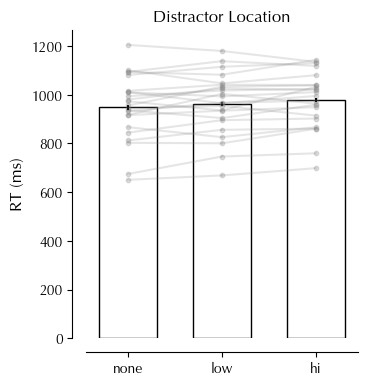

In [151]:
#this is script taken form a different experiment with different variable names, so be careful that it works with your data!

# step 1: plot results as a function of dist location 
plt.figure(figsize=(3.5, 4))
pivot = df[(df.RT_filter) & 
# (df.D_D == -1) & 
(df.correct == 1)].pivot_table(values = 'RT', columns = ['dist'], 
                    index = 'id', aggfunc='mean')

headers = [f'{cnd}' for cnd in ['nd','low','hi']]
values = [pivot[cnd].values for cnd in ['nd','low','hi']]

# Compute within-subject confidence intervals corrected using the Cousineau-Morey method
ci_low, ci_high = cousineau_morey_ci(np.array(values).T)

plt.bar([0.8,1.2,1.6], np.array(values).mean(axis = 1), width = 0.25,
            color = 'white', edgecolor = 'black', yerr=[np.array(values).mean(axis = 1) - ci_low, ci_high - np.array(values).mean(axis = 1)])

plt.scatter([[x] * len(values[0]) for x in [0.8,1.2,1.6]], values, c = 'grey', alpha = 0.25, s = 10)

plt.plot([0.8,1.2],np.array(values)[:2,:], color = 'grey', alpha = 0.2)
plt.plot([1.2,1.6],np.array(values)[1:,:], color = 'grey', alpha = 0.2)
# plt.xticks([1,2], ['biased side','neutral side'])

plt.title('Distractor Location')
plt.ylabel('RT (ms)')
plt.xticks([0.8,1.2,1.6], ['none', 'low', 'hi'])
plt.ylabel('RT (ms)')
# plt.ylim(400,600)
sns.despine(offset = 10)

print(ttest_rel(pivot['low'], pivot['hi']))
# print(ttest_rel(pivot['hp'], pivot['nd']))

# Create the AnovaRM object
pivot.reset_index(inplace=True)
pivot_long = pd.melt(pivot, id_vars=['id'], value_vars=['nd', 'low', 'hi'],
                  var_name='dist', value_name='rt')
# print(AnovaRM(pivot_long, depvar='rt', subject='total_id', within=['dist_cond']).fit())

aov = pg.rm_anova(dv='rt', within='dist', subject='id', data=pivot_long, detailed=True)
print(aov)

# Display the effect size
f_value = aov.loc[0, 'F']
p_value = aov.loc[0, 'p-unc']
eta_squared = aov.loc[0, 'ng2']
print(f"f value: {f_value:.3f}")
print(f"p value: {p_value:.3f}")
print(f"Partial Eta Squared: {eta_squared:.3f}")


L vs H:
------------------------------------------------------------
Paired t-test: t(22) = -2.129, p = 0.04466
95% CI [-29.96, -0.3955]
Cohen's d: -0.4440, 95% CI [-0.8972, 0.009242]

📋 Manuscript format: t(22) = -2.129, p = 0.04466, d = -0.4440, 95% CI [-29.96, -0.3955]

L vs ND:
------------------------------------------------------------
Paired t-test: t(22) = 1.605, p = 0.1229
95% CI [-4.009, 31.42]
Cohen's d: 0.3346, 95% CI [-0.1098, 0.7789]

📋 Manuscript format: t(22) = 1.605, p = 0.1229, d = 0.3346, 95% CI [-4.009, 31.42]

H vs ND:
------------------------------------------------------------
Paired t-test: t(22) = 3.731, p = 0.001160
95% CI [12.83, 44.94]
Cohen's d: 0.7779, 95% CI [0.2844, 1.271]

📋 Manuscript format: t(22) = 3.731, p = 0.001160, d = 0.7779, 95% CI [12.83, 44.94]


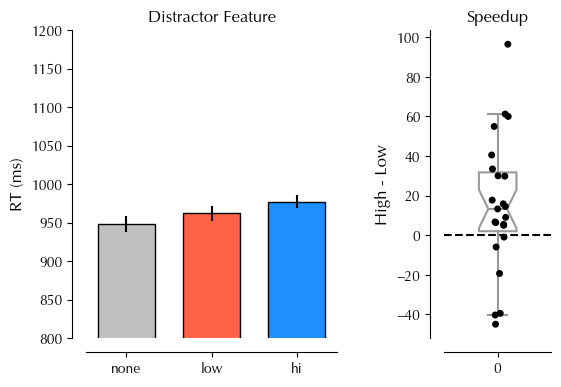

In [152]:
# Create a new figure to accommodate both plots
fig = plt.figure(figsize=(6, 4))  # Adjust the size as needed

# Create a GridSpec object
gs = fig.add_gridspec(1, 2, width_ratios=[3.5, 1.5], wspace=0.6)

# First subplot
ax1 = fig.add_subplot(gs[0, 0])
pivot = df[(df.RT_filter) & 
# (df.D_D == -1) & 
# (df.daxis == 'horizontal') & 
(df.correct == 1)].pivot_table(values = 'RT', columns = ['dist'], 
                    index = 'id', aggfunc='mean')

headers = [f'{cnd}' for cnd in ['nd','low','hi']]
values = [pivot[cnd].values for cnd in ['nd','low','hi']]
col = ['silver','tomato','dodgerblue']

# Compute within-subject confidence intervals corrected using the Cousineau-Morey method
ci_low, ci_high = cousineau_morey_ci(np.array(values).T)

ax1.bar([0.8,1.1,1.4], np.array(values).mean(axis = 1), width = 0.2,
            color = col, edgecolor = 'black', yerr=[np.array(values).mean(axis = 1) - ci_low, ci_high - np.array(values).mean(axis = 1)])

ax1.set_title('Distractor Feature')
ax1.set_ylabel('RT (ms)')
ax1.set_ylim(800,1200)
ax1.set_xticks([0.8,1.1,1.4])
ax1.set_xticklabels(['none','low','hi'])
sns.despine(offset = 10, ax=ax1)

results = paired_ttest_analysis(pivot['low'], pivot['hi'], 'L', 'H')
results = paired_ttest_analysis(pivot['low'], pivot['nd'], 'L', 'ND')
results = paired_ttest_analysis(pivot['hi'], pivot['nd'], 'H', 'ND')

# Second subplot
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title('Speedup')
ax2.set_ylabel('High - Low')

diff = pivot['hi'] - pivot['low']

ax2.axhline(y=0, color='black', ls='--') 

sns.boxplot(y=diff, width=0.35, notch=True, color='white', fliersize=0, ax=ax2)
sns.stripplot(data=np.array(diff), jitter=True, color='black', ax=ax2)
# ax2.set_ylim(-70,20)
sns.despine(offset = 10, ax=ax2)

# plt.tight_layout()

# Save the combined figure
plt.savefig(os.path.join(download_folder, './color_beh.png'), bbox_inches='tight')

plt.show()


In [153]:
pivot

dist,hi,low,nd
id,,,
5aad4225811b2000016f6ed1,759.555556,746.299363,674.766667
5d9e3ec9611b0b0017b14b9a,902.371069,895.679739,844.516129
5dd05d80b2204f1487f7812c,1032.213836,935.754491,972.985507
5ea9a6a68db51d0dfd2edfe2,1024.050633,1017.715152,994.161765
5f01b7e94738d231487f2911,860.666667,800.684524,802.600000
5f70f2daea9a9f7076484982,914.493750,953.973154,945.769231
606cf604adbb6982bb382881,1134.920732,1179.903030,1204.808824
60fef19b9c12d84b5a87fa1d,866.412121,825.906832,866.859375
64c9892e8e7e06812b775c0c,1080.275168,1046.818182,1100.515625


        Source             SS   DF           MS         F     p-unc       ng2  \
0  food_rating   25031.779347    9  2781.308816  1.611196  0.114069  0.007131   
1        Error  341795.289941  198  1726.238838       NaN       NaN       NaN   

       eps  
0  0.68675  
1      NaN  


/var/folders/w3/s9kgwbfx5_ld501nzjnz8jgr0000gn/T/ipykernel_49017/1431654898.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('viridis')


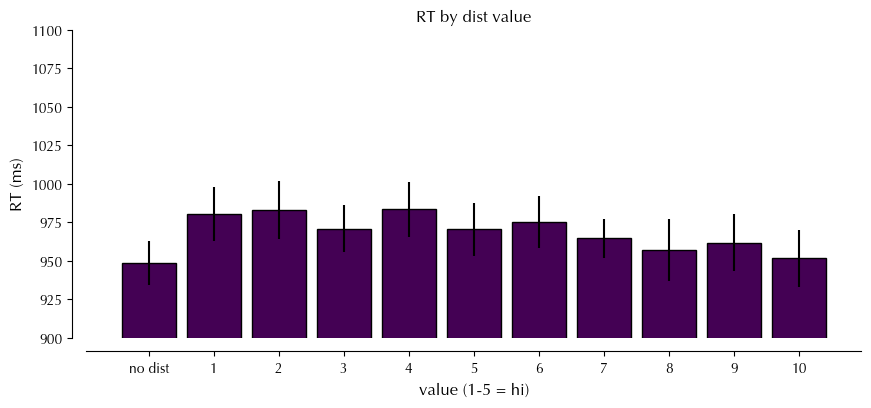

In [154]:
# step 1: plot results as a function of food preference ranking (1=best, 12=worst)
plt.figure(figsize=(10, 4))
pivot = df[(df.RT_filter) & 
(df.correct == 1)].pivot_table(values = 'RT', columns = ['dist_col'], 
                    index = 'id', aggfunc='mean')

headers = [f'{cnd}' for cnd in ['99','1','2','3','4','5','6','7','8','9','10']]
values = [pivot[cnd].values for cnd in [99,0,1,2,3,4,5,6,7,8,9]]

cmap = plt.cm.get_cmap('viridis')
col = [cmap(i/12) for i in range(1)]

# Compute within-subject confidence intervals corrected using the Cousineau-Morey method
ci_low, ci_high = cousineau_morey_ci(np.array(values).T)

positions = [0.5 + i*0.3 for i in range(11)]
plt.bar(positions, np.array(values).mean(axis = 1), width = 0.25,
            color = col, edgecolor = 'black', yerr=[np.array(values).mean(axis = 1) - ci_low, ci_high - np.array(values).mean(axis = 1)])

plt.title('RT by dist value')
plt.ylabel('RT (ms)')
plt.xlabel('value (1-5 = hi)')
plt.ylim(900,1100)
plt.xticks(positions, ['no dist','1','2','3','4','5','6','7','8','9','10'])
sns.despine(offset = 10)

# Repeated measures ANOVA
pivot.reset_index(inplace=True)
pivot_long = pd.melt(pivot, id_vars=['id'], value_vars=[0,1,2,3,4,5,6,7,8,9],
                  var_name='food_rating', value_name='RT')
print("=" * 70)
aov = pg.rm_anova(dv='RT', within='food_rating', subject='id', data=pivot_long, detailed=True)
print(aov)
print("=" * 70)

# plt.savefig(os.path.join(download_folder, './food_preference_spectrum.png'), bbox_inches='tight')

# results = {
#     headers[0]: values[0],
#     headers[1]: values[1],
#     headers[2]: values[2],
#     headers[3]: values[3],
#     headers[4]: values[4],
#     headers[5]: values[5],
#     headers[6]: values[6],
#     headers[7]: values[7],
#     headers[8]: values[8],
#     headers[9]: values[9],
#     headers[10]: values[10],
#     headers[11]: values[11],
# }

# results = pd.DataFrame(results)

# results.to_csv('food_preference_gradient.csv', index=False)

        Source             SS   DF           MS         F     p-unc       ng2  \
0  food_rating   25031.779347    9  2781.308816  1.611196  0.114069  0.007131   
1        Error  341795.289941  198  1726.238838       NaN       NaN       NaN   

       eps  
0  0.68675  
1      NaN  


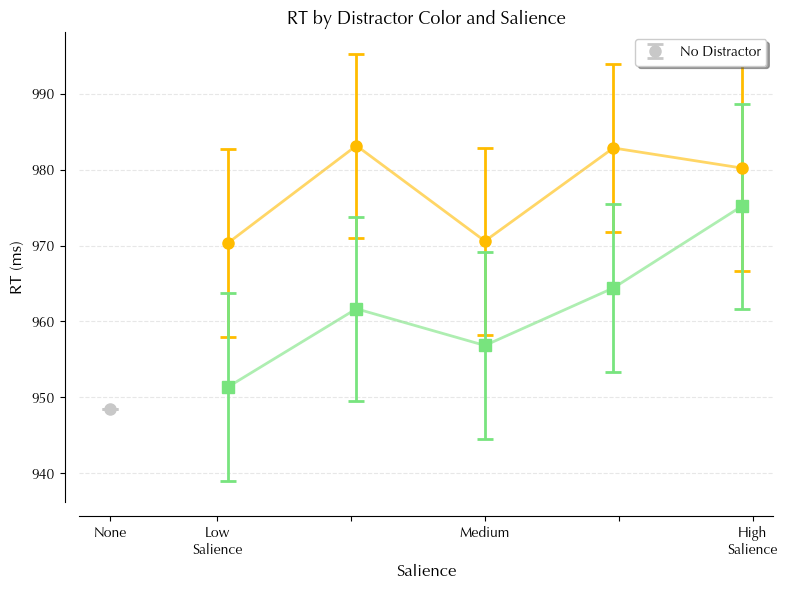

In [ ]:

# step 1: plot results as a function of distractor color/salience
# 0-4 red (high to low salience), 5-9 green (high to low salience)
# X-axis: salience (0/5=high, 4/9=low), Color: red vs green, Overlapping points
fig, ax = plt.subplots(figsize=(8, 6))

pivot = df[(df.RT_filter) & 
(df.correct == 1)].pivot_table(values = 'RT', columns = ['dist_col'], 
                    index = 'id', aggfunc='mean')

# Separate no-distractor (99) from colored distractors (0-9, which are indexed as 1-10 in pivot)
no_dist_data = pivot[99].values if 99 in pivot.columns else None
colored_dist_data = [pivot[i].values if i in pivot.columns else None for i in range(0, 10)]

# Map distractor indices to salience levels:
# Red (0-4): salience 4-0 (reversed: 4=low, 0=high)
# Green (5-9): salience 4-0 (reversed: 4=low, 0=high) - mapped from indices 5-9
# So: 0->salience 4, 1->salience 3, 2->salience 2, 3->salience 1, 4->salience 0, 5->salience 4, etc.

salience_mapping = [4, 3, 2, 1, 0, 4, 3, 2, 1, 0]  # Salience level for each distractor index (reversed)
color_mapping = ['red', 'red', 'red', 'red', 'red', 'green', 'green', 'green', 'green', 'green']  # Color for each

# Group data by salience level first to calculate CIs per salience pair (red vs green)
salience_data = {sal: {'red': [], 'green': [], 'x_red': [], 'x_green': []} for sal in range(5)}

# Collect raw data organized by salience level (separating red and green)
for dist_idx in range(0, 10):
    if colored_dist_data[dist_idx] is not None:
        salience_level = salience_mapping[dist_idx]
        color_type = color_mapping[dist_idx]
        if color_type == 'red':
            salience_data[salience_level]['red'].append(colored_dist_data[dist_idx])
        else:
            salience_data[salience_level]['green'].append(colored_dist_data[dist_idx])

# Calculate CIs for each salience level (for the pair of red and green at that level)
salience_ci = {}
for sal in range(5):
    red_data = salience_data[sal]['red']
    green_data = salience_data[sal]['green']
    
    if red_data and green_data:
        # Both red and green exist at this salience level
        pair_data = [np.array(red_data), np.array(green_data)]
        ci_low, ci_high = cousineau_morey_ci(np.vstack(pair_data).T)
        salience_ci[sal] = {'ci_low': ci_low, 'ci_high': ci_high, 'red_idx': 0, 'green_idx': 1}
    elif red_data:
        # Only red exists
        ci_low, ci_high = cousineau_morey_ci(np.array(red_data).T)
        salience_ci[sal] = {'ci_low': ci_low, 'ci_high': ci_high, 'red_idx': 0, 'green_idx': None}
    elif green_data:
        # Only green exists
        ci_low, ci_high = cousineau_morey_ci(np.array(green_data).T)
        salience_ci[sal] = {'ci_low': ci_low, 'ci_high': ci_high, 'red_idx': None, 'green_idx': 0}

# Compute no-distractor CI
if no_dist_data is not None:
    no_dist_ci_low, no_dist_ci_high = cousineau_morey_ci(np.array([no_dist_data]).T)

# Plot no-distractor baseline
if no_dist_data is not None:
    mean_val = no_dist_data.mean()
    err_low = np.abs(mean_val - no_dist_ci_low[0])
    err_high = np.abs(no_dist_ci_high[0] - mean_val)
    ax.errorbar(0.2, mean_val, yerr=[[err_low], [err_high]],
                marker='o', markersize=8, linewidth=0, capsize=6, capthick=2,
                color='#C8C8C8', elinewidth=2, zorder=3, label='No Distractor')

# Small offsets for overlapping visualization
offsets = [-0.08, -0.04, 0, 0.04, 0.08]
offset_idx = 0

# Plot individual points with error bars based on salience-level CIs
for dist_idx, dist_num in enumerate(range(0, 10)):
    if colored_dist_data[dist_idx] is not None:
        mean_val = colored_dist_data[dist_idx].mean()
        salience_level = salience_mapping[dist_idx]
        color_type = color_mapping[dist_idx]
        
        # Get CI for this salience level
        ci_info = salience_ci[salience_level]
        ci_low_vals = ci_info['ci_low']
        ci_high_vals = ci_info['ci_high']
        
        # Determine which index corresponds to this color
        if color_type == 'red':
            ci_idx = ci_info['red_idx']
            color = '#FFBC00'
            marker = 'o'
        else:
            ci_idx = ci_info['green_idx']
            color = '#78E47E'
            marker = 's'
        
        # Get error bar values for this specific color
        if ci_idx is not None:
            err_low = np.abs(mean_val - ci_low_vals[ci_idx])
            err_high = np.abs(ci_high_vals[ci_idx] - mean_val)
        else:
            err_low = err_high = 0
        
        # X-position: salience level (1-5 for display) with offset
        base_x = salience_level + 1  # 1-5 on x-axis
        x_offset = offsets[offset_idx % 5]
        x_pos = base_x + x_offset
        offset_idx += 1
        
        # Store data for connecting lines
        if color_type == 'red':
            salience_data[salience_level]['x_red'].append(x_pos)
            color_marker = '#FFBC00'
        else:
            salience_data[salience_level]['x_green'].append(x_pos)
            color_marker = '#78E47E'
        
        # Plot point with error bars
        ax.errorbar(x_pos, mean_val, yerr=[[err_low], [err_high]],
                    marker=marker, markersize=8, linewidth=0, capsize=6, capthick=2,
                    color=color, elinewidth=2, zorder=2)

# Add connecting lines for red group (0-4)
red_x_all = []
red_y_all = []
for sal in range(5):
    if salience_data[sal]['red']:
        # Use average x position for red
        avg_x = np.mean(salience_data[sal]['x_red'])
        avg_y = np.mean(salience_data[sal]['red'])
        red_x_all.append(avg_x)
        red_y_all.append(avg_y)

if len(red_x_all) > 1:
    ax.plot(red_x_all, red_y_all, color='#FFBC00', linewidth=2, alpha=0.6, zorder=1)

# Add connecting lines for green group (5-9)
green_x_all = []
green_y_all = []
for sal in range(5):
    if salience_data[sal]['green']:
        # Use average x position for green
        avg_x = np.mean(salience_data[sal]['x_green'])
        avg_y = np.mean(salience_data[sal]['green'])
        green_x_all.append(avg_x)
        green_y_all.append(avg_y)

if len(green_x_all) > 1:
    ax.plot(green_x_all, green_y_all, color='#78E47E', linewidth=2, alpha=0.6, zorder=1)

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFBC00', markersize=8, label='Orange: High Value'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#78E47E', markersize=8, label='Green: Low Value'),
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True, shadow=True, fontsize=10)

ax.set_xticks([0.2, 1, 2, 3, 4, 5])
ax.set_xticklabels(['None', 'Low\nSalience', '', 'Medium', '', 'High\nSalience'])
ax.set_xlabel('Salience', fontsize=12)
ax.set_ylabel('RT (ms)', fontsize=12)
ax.set_title('RT by Distractor Color and Salience', fontsize=13, fontweight='bold')
# ax.set_xlim(0.5, 3.5)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=10)
sns.despine(ax=ax, offset=10)
plt.tight_layout()

# Repeated measures ANOVA
pivot.reset_index(inplace=True)
pivot_long = pd.melt(pivot, id_vars=['id'], value_vars=[0,1,2,3,4,5,6,7,8,9],
                  var_name='dist_col', value_name='RT')
print("=" * 70)
aov = pg.rm_anova(dv='RT', within='dist_col', subject='id', data=pivot_long, detailed=True)
print(aov)
print("=" * 70)

# plt.savefig(os.path.join(download_folder, './food_preference_spectrum.png'), bbox_inches='tight')


KeyError: 'food_rank'

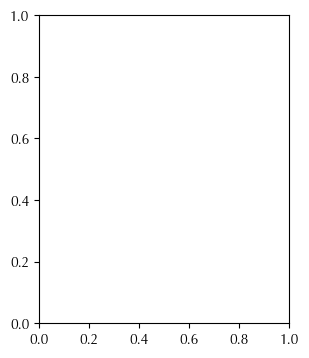

In [156]:
# Create a new figure to accommodate both plots
fig = plt.figure(figsize=(6, 4))  # Adjust the size as needed

# Create a GridSpec object
gs = fig.add_gridspec(1, 2, width_ratios=[3.5, 1.5], wspace=0.6)

# First subplot
ax1 = fig.add_subplot(gs[0, 0])
pivot = df[(df.RT_filter) & 
# (df.block>-1)&
# (df.T_T == -1) & 
# (df.daxis == 'horizontal') & 
(df.dist == 'real') &
(df.correct == 1)].pivot_table(values = 'RT', columns = ['food_rank'], 
                    index = 'id', aggfunc='mean')

# Columns come out alphabetically: ['alt', 'rep']
headers = [f'{cnd}' for cnd in ['best','worst']]
values = [pivot[cnd].values for cnd in [1,12]]
col = ['limegreen','violet']

# Compute within-subject confidence intervals corrected using the Cousineau-Morey method
ci_low, ci_high = cousineau_morey_ci(np.array(values).T)

ax1.bar([0.8,1.1], np.array(values).mean(axis = 1), width = 0.2,
            color = col, edgecolor = 'black', yerr=[np.array(values).mean(axis = 1) - ci_low, ci_high - np.array(values).mean(axis = 1)])

ax1.set_title('Preference Effect')
ax1.set_ylabel('RT (ms)')
plt.ylim(600,650)
ax1.set_xticks([0.8,1.1])
ax1.set_xticklabels(['best', 'worst'])
sns.despine(offset = 10, ax=ax1)

# print(ttest_rel(pivot['re], pivot['alt']))
# mean_diff = np.mean(pivot['rep'] - pivot['alt'])
# std_diff = np.std(pivot['rep'] - pivot['alt'], ddof=1)
# cohens_d = mean_diff / std_diff
# print(f"Cohen's d: {cohens_d:.3f}")

# print(ttest_rel(pivot['hp'], pivot['nd']))

# Second subplot
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title('Speedup')
ax2.set_ylabel('best - worst')

diff = pivot[1] - pivot[12]

ax2.axhline(y=0, color='black', ls='--') 

sns.boxplot(y=diff, width=0.35, notch=True, color='white', fliersize=0, ax=ax2)
sns.stripplot(data=np.array(diff), jitter=True, color='black', ax=ax2)
# ax2.set_ylim(-70,20)
sns.despine(offset = 10, ax=ax2)

# plt.tight_layout()

# Save the combined figure
# plt.savefig(os.path.join(fig_fol, './grand_average_beh.png'), bbox_inches='tight')

plt.show()
results = paired_ttest_analysis(pivot[1], pivot[12], 'best', 'worst')


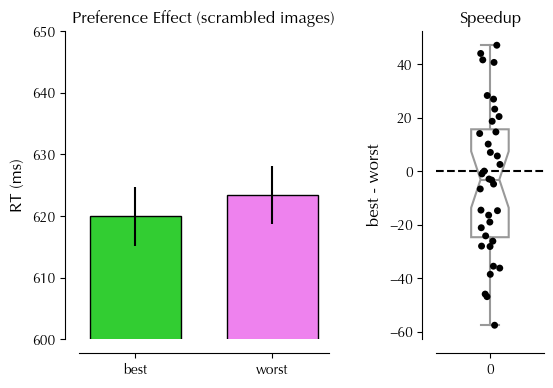


best vs worst:
------------------------------------------------------------
Paired t-test: t(35) = -0.7649, p = 0.4495
95% CI [-12.87, 5.825]
Cohen's d: -0.1275, 95% CI [-0.4672, 0.2122]

📋 Manuscript format: t(35) = -0.7649, p = 0.4495, d = -0.1275, 95% CI [-12.87, 5.825]


In [ ]:
# Create a new figure to accommodate both plots
fig = plt.figure(figsize=(6, 4))  # Adjust the size as needed

# Create a GridSpec object
gs = fig.add_gridspec(1, 2, width_ratios=[3.5, 1.5], wspace=0.6)

# First subplot
ax1 = fig.add_subplot(gs[0, 0])
pivot = df[(df.RT_filter) & 
# (df.block>-1)&
# (df.T_T == -1) & 
# (df.daxis == 'horizontal') & 
(df.dist == 'fake') &
(df.correct == 1)].pivot_table(values = 'RT', columns = ['food_rank'], 
                    index = 'id', aggfunc='mean')

# Columns come out alphabetically: ['alt', 'rep']
headers = [f'{cnd}' for cnd in ['best','worst']]
values = [pivot[cnd].values for cnd in [1,12]]
col = ['limegreen','violet']

# Compute within-subject confidence intervals corrected using the Cousineau-Morey method
ci_low, ci_high = cousineau_morey_ci(np.array(values).T)

ax1.bar([0.8,1.1], np.array(values).mean(axis = 1), width = 0.2,
            color = col, edgecolor = 'black', yerr=[np.array(values).mean(axis = 1) - ci_low, ci_high - np.array(values).mean(axis = 1)])

ax1.set_title('Preference Effect (scrambled images)')
ax1.set_ylabel('RT (ms)')
plt.ylim(600,650)
ax1.set_xticks([0.8,1.1])
ax1.set_xticklabels(['best', 'worst'])
sns.despine(offset = 10, ax=ax1)

# print(ttest_rel(pivot['re], pivot['alt']))
# mean_diff = np.mean(pivot['rep'] - pivot['alt'])
# std_diff = np.std(pivot['rep'] - pivot['alt'], ddof=1)
# cohens_d = mean_diff / std_diff
# print(f"Cohen's d: {cohens_d:.3f}")

# print(ttest_rel(pivot['hp'], pivot['nd']))

# Second subplot
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title('Speedup')
ax2.set_ylabel('best - worst')

diff = pivot[1] - pivot[12]

ax2.axhline(y=0, color='black', ls='--') 

sns.boxplot(y=diff, width=0.35, notch=True, color='white', fliersize=0, ax=ax2)
sns.stripplot(data=np.array(diff), jitter=True, color='black', ax=ax2)
# ax2.set_ylim(-70,20)
sns.despine(offset = 10, ax=ax2)

# plt.tight_layout()

# Save the combined figure
# plt.savefig(os.path.join(fig_fol, './grand_average_beh.png'), bbox_inches='tight')

plt.show()
results = paired_ttest_analysis(pivot[1], pivot[12], 'best', 'worst')


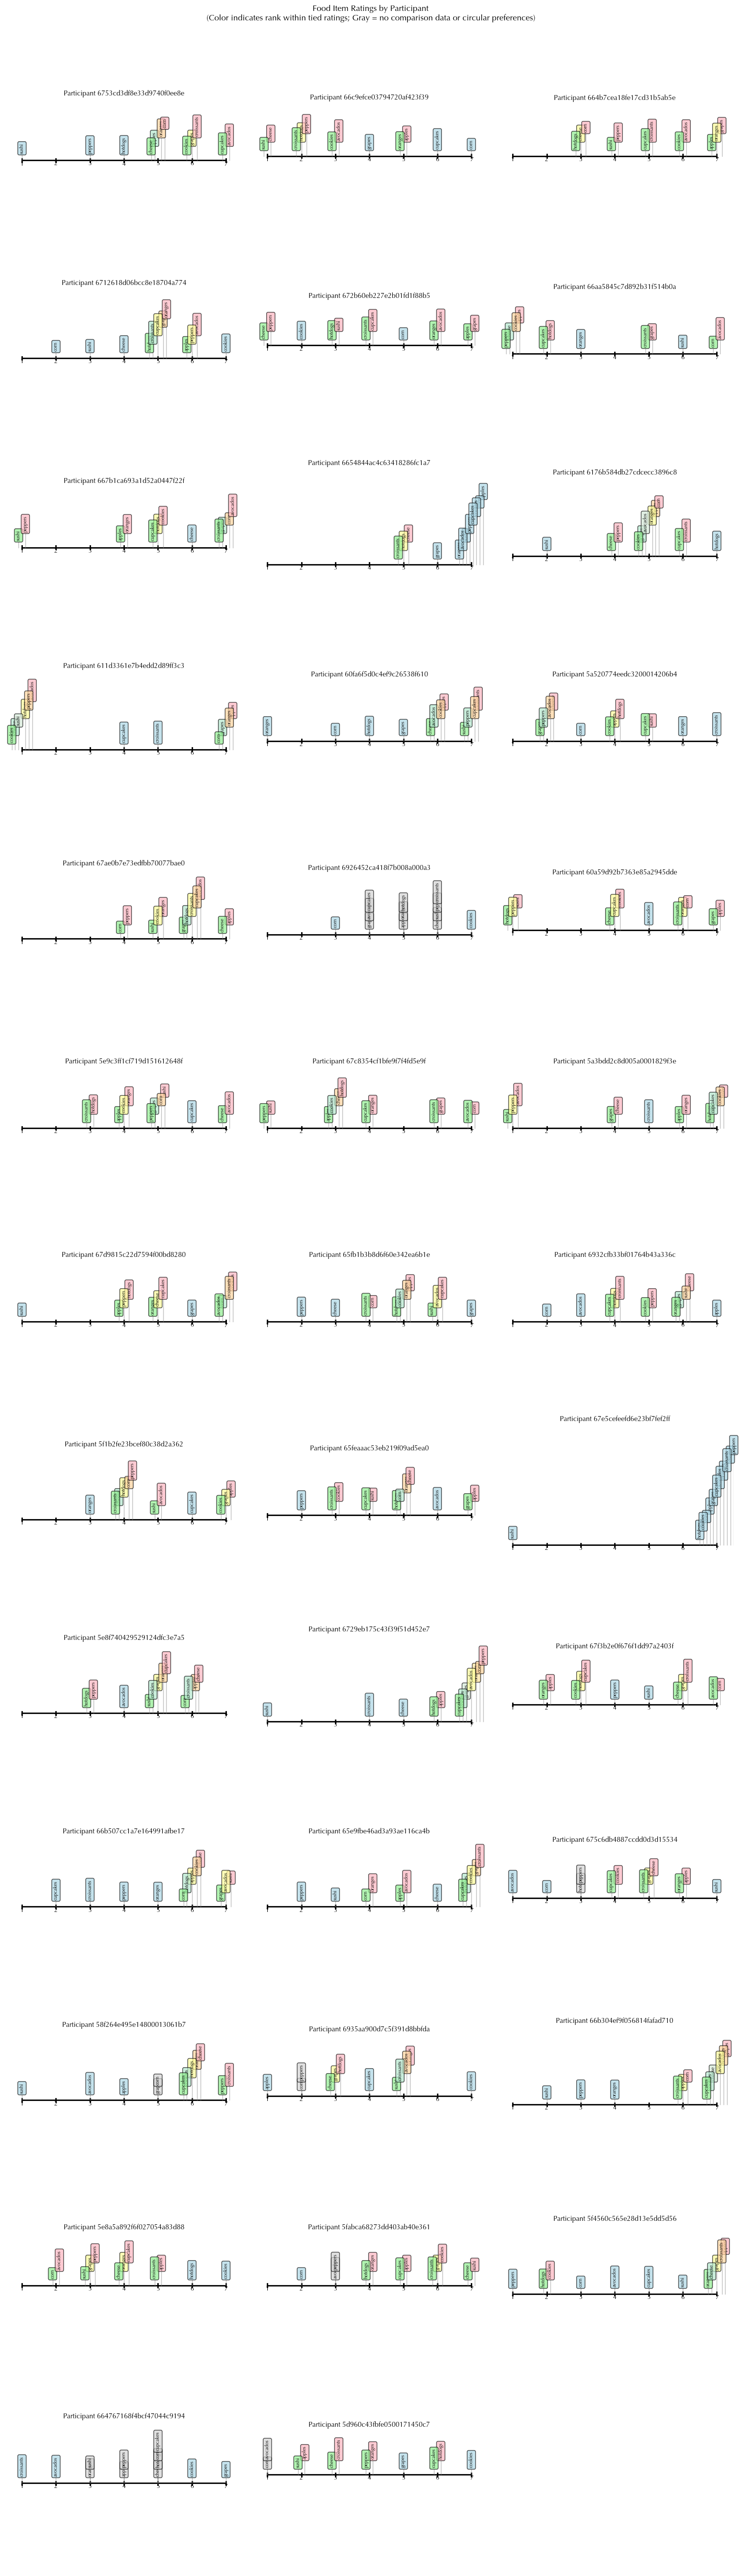

✓ Created rating visualization for 38 participants


In [ ]:
# Map food stimulus indices to names (in order, 0-indexed)
food_names = [
    'apples', 'grapes', 'oranges', 'cheese', 'hotdogs', 'sushi',
    'corn', 'avocados', 'peppers', 'cookies', 'croissants', 'cupcakes'
]

# Collect all participant data first
all_participant_data = []

for pid in df_posttest['id'].unique():
    participant_data = df_posttest[df_posttest['id'] == pid]
    
    if len(participant_data) > 0:
        ratings_raw = participant_data['ratings'].iloc[0]
        
        try:
            # Parse ratings
            if isinstance(ratings_raw, str):
                ratings_str_cleaned = ratings_raw.replace(', ', ',').replace(' ', '')
                ratings = literal_eval(ratings_str_cleaned)
            elif isinstance(ratings_raw, list):
                ratings = ratings_raw
            else:
                ratings = list(ratings_raw)
            
            if len(ratings) != len(food_names):
                print(f"Warning: Participant {pid} has invalid ratings")
                continue
            
            # Build comparison matrix from pairwise comparisons
            comparison_rows = participant_data[['left_stim', 'right_stim', 'response']]
            comparison_wins = {}  # (food1_idx, food2_idx) -> winner_idx
            
            for _, row in comparison_rows.iterrows():
                left_name = row['left_stim']
                right_name = row['right_stim']
                
                if left_name in food_names and right_name in food_names:
                    left_idx = food_names.index(left_name)
                    right_idx = food_names.index(right_name)
                    
                    if row['response'] == 'left':
                        comparison_wins[(left_idx, right_idx)] = left_idx
                        comparison_wins[(right_idx, left_idx)] = left_idx
                    elif row['response'] == 'right':
                        comparison_wins[(left_idx, right_idx)] = right_idx
                        comparison_wins[(right_idx, left_idx)] = right_idx
            
            # Group foods by their base rating
            rating_groups = {}
            for idx, rating in enumerate(ratings):
                rating_val = float(rating)
                if rating_val not in rating_groups:
                    rating_groups[rating_val] = []
                rating_groups[rating_val].append(idx)
            
            # Calculate positions for each rating group
            food_positions = {}
            max_items_at_rating = 0
            
            # Color palette for different ranks within a rating
            color_palettes = {
                1: ['lightblue'],
                2: ['#90EE90', '#FFB6C1'],  # light green, light pink
                3: ['#90EE90', '#FFFF99', '#FFB6C1'],  # green, yellow, pink
                4: ['#90EE90', '#B4E7CE', '#FFD59E', '#FFB6C1'],  # gradient
                5: ['#90EE90', '#B4E7CE', '#FFFF99', '#FFD59E', '#FFB6C1'],
                6: ['#90EE90', '#B4E7CE', '#D4E7D7', '#FFFF99', '#FFD59E', '#FFB6C1'],
                7: ['#90EE90', '#B4E7CE', '#D4E7D7', '#FFFF99', '#FFE59E', '#FFD59E', '#FFB6C1']
            }
            
            for rating_val, food_indices in rating_groups.items():
                n_items = len(food_indices)
                max_items_at_rating = max(max_items_at_rating, n_items)
                
                if n_items == 1:
                    # Single item - no displacement
                    ranked_indices = food_indices
                    offsets = [0]
                    colors = color_palettes[1]
                else:
                    # Rank items within this rating based on comparisons
                    # Calculate win count among items in this group
                    win_counts = {}
                    for food_idx in food_indices:
                        wins = 0
                        for other_idx in food_indices:
                            if food_idx != other_idx:
                                if (food_idx, other_idx) in comparison_wins:
                                    if comparison_wins[(food_idx, other_idx)] == food_idx:
                                        wins += 1
                        win_counts[food_idx] = wins
                    
                    # Check for circular preferences (all have same win count)
                    unique_wins = set(win_counts.values())
                    is_circular = len(unique_wins) == 1 and n_items > 1
                    
                    # Check if any comparisons exist
                    has_comparisons = any((food_indices[i], food_indices[j]) in comparison_wins 
                                         for i in range(len(food_indices)) 
                                         for j in range(i+1, len(food_indices)))
                    
                    if not has_comparisons or is_circular:
                        # No comparisons or circular - show overlapping
                        ranked_indices = food_indices
                        offsets = [0] * n_items
                        colors = ['lightgray'] * n_items
                    else:
                        # Rank by win count (descending)
                        ranked_indices = sorted(food_indices, key=lambda x: win_counts[x], reverse=True)
                        
                        # Calculate offsets based on rank
                        if n_items == 2:
                            offsets = [-0.1, 0.1]  # ±0.1
                        elif n_items == 3:
                            offsets = [-0.15, 0, 0.15]  # -0.15, centered, +0.15
                        elif n_items == 4:
                            offsets = [-0.2, -0.1, 0.1, 0.2]  # ±0.2, ±0.1
                        elif n_items == 5:
                            offsets = [-0.25, -0.15, 0, 0.15, 0.25]
                        elif n_items == 6:
                            offsets = [-0.3, -0.2, -0.1, 0.1, 0.2, 0.3]
                        elif n_items == 7:
                            offsets = [-0.35, -0.25, -0.15, 0, 0.15, 0.25, 0.35]
                        else:
                            # Fallback for > 7 items
                            step = 0.1
                            offsets = [(i - (n_items-1)/2) * step for i in range(n_items)]
                        
                        colors = color_palettes.get(n_items, ['lightblue'] * n_items)
                
                # Assign positions
                for rank, food_idx in enumerate(ranked_indices):
                    x_pos = rating_val + offsets[rank]
                    
                    food_positions[food_idx] = {
                        'x': x_pos,
                        'y': 0.2 + (rank * 0.25),
                        'name': food_names[food_idx],
                        'color': colors[rank],
                        'rank': rank + 1,
                        'n_items': n_items
                    }
            
            # Store participant data
            all_participant_data.append({
                'pid': pid,
                'food_positions': food_positions,
                'max_items_at_rating': max_items_at_rating
            })
            
        except Exception as e:
            print(f"Skipping participant {pid}: {str(e)}")
            import traceback
            traceback.print_exc()
            continue

# Create grid figure with 3 columns
n_participants = len(all_participant_data)
n_cols = 3
n_rows = int(np.ceil(n_participants / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten() if n_participants > 1 else [axes]

for idx, pdata in enumerate(all_participant_data):
    ax = axes[idx]
    pid = pdata['pid']
    food_positions = pdata['food_positions']
    max_items_at_rating = pdata['max_items_at_rating']
    
    # Draw number line
    ax.plot([1, 7], [0, 0], 'k-', linewidth=2)
    
    # Draw tick marks and labels
    for rating in range(1, 8):
        ax.plot([rating, rating], [-0.05, 0.05], 'k-', linewidth=2)
        ax.text(rating, -0.15, str(rating), ha='center', fontsize=9, fontweight='bold')
    
    # Place food names at their calculated positions
    for food_idx in range(len(food_names)):
        pos = food_positions[food_idx]
        
        # Draw line from food name to rating position
        ax.plot([pos['x'], pos['x']], [0, pos['y'] - 0.05], 'gray', alpha=0.5, linewidth=1)
        
        # Place food name with text rotated upward (90 degrees)
        ax.text(pos['x'], pos['y'], pos['name'], ha='center', va='bottom', fontsize=7,
               rotation=90,
               bbox=dict(boxstyle='round,pad=0.3', facecolor=pos['color'], alpha=0.7))
    
    # Set axis properties
    ax.set_xlim(0.5, 7.5)
    y_max = 0.2 + (max_items_at_rating * 0.25) + 0.5
    ax.set_ylim(-0.3, y_max)
    ax.set_aspect('equal', adjustable='box')
    ax.axis('off')
    
    # Add title
    ax.set_title(f'Participant {pid}', fontsize=10, fontweight='bold', pad=10)

# Hide extra subplots if any
for idx in range(n_participants, len(axes)):
    axes[idx].axis('off')

# Add overall title
fig.suptitle('Food Item Ratings by Participant\n(Color indicates rank within tied ratings; Gray = no comparison data or circular preferences)', 
             fontsize=12, fontweight='bold', y=0.995)

plt.tight_layout()

# Save figure
fig.savefig(os.path.join(download_folder, 'all_participants_ratings.png'), 
           bbox_inches='tight', dpi=150)

plt.show()

print(f"✓ Created rating visualization for {n_participants} participants")

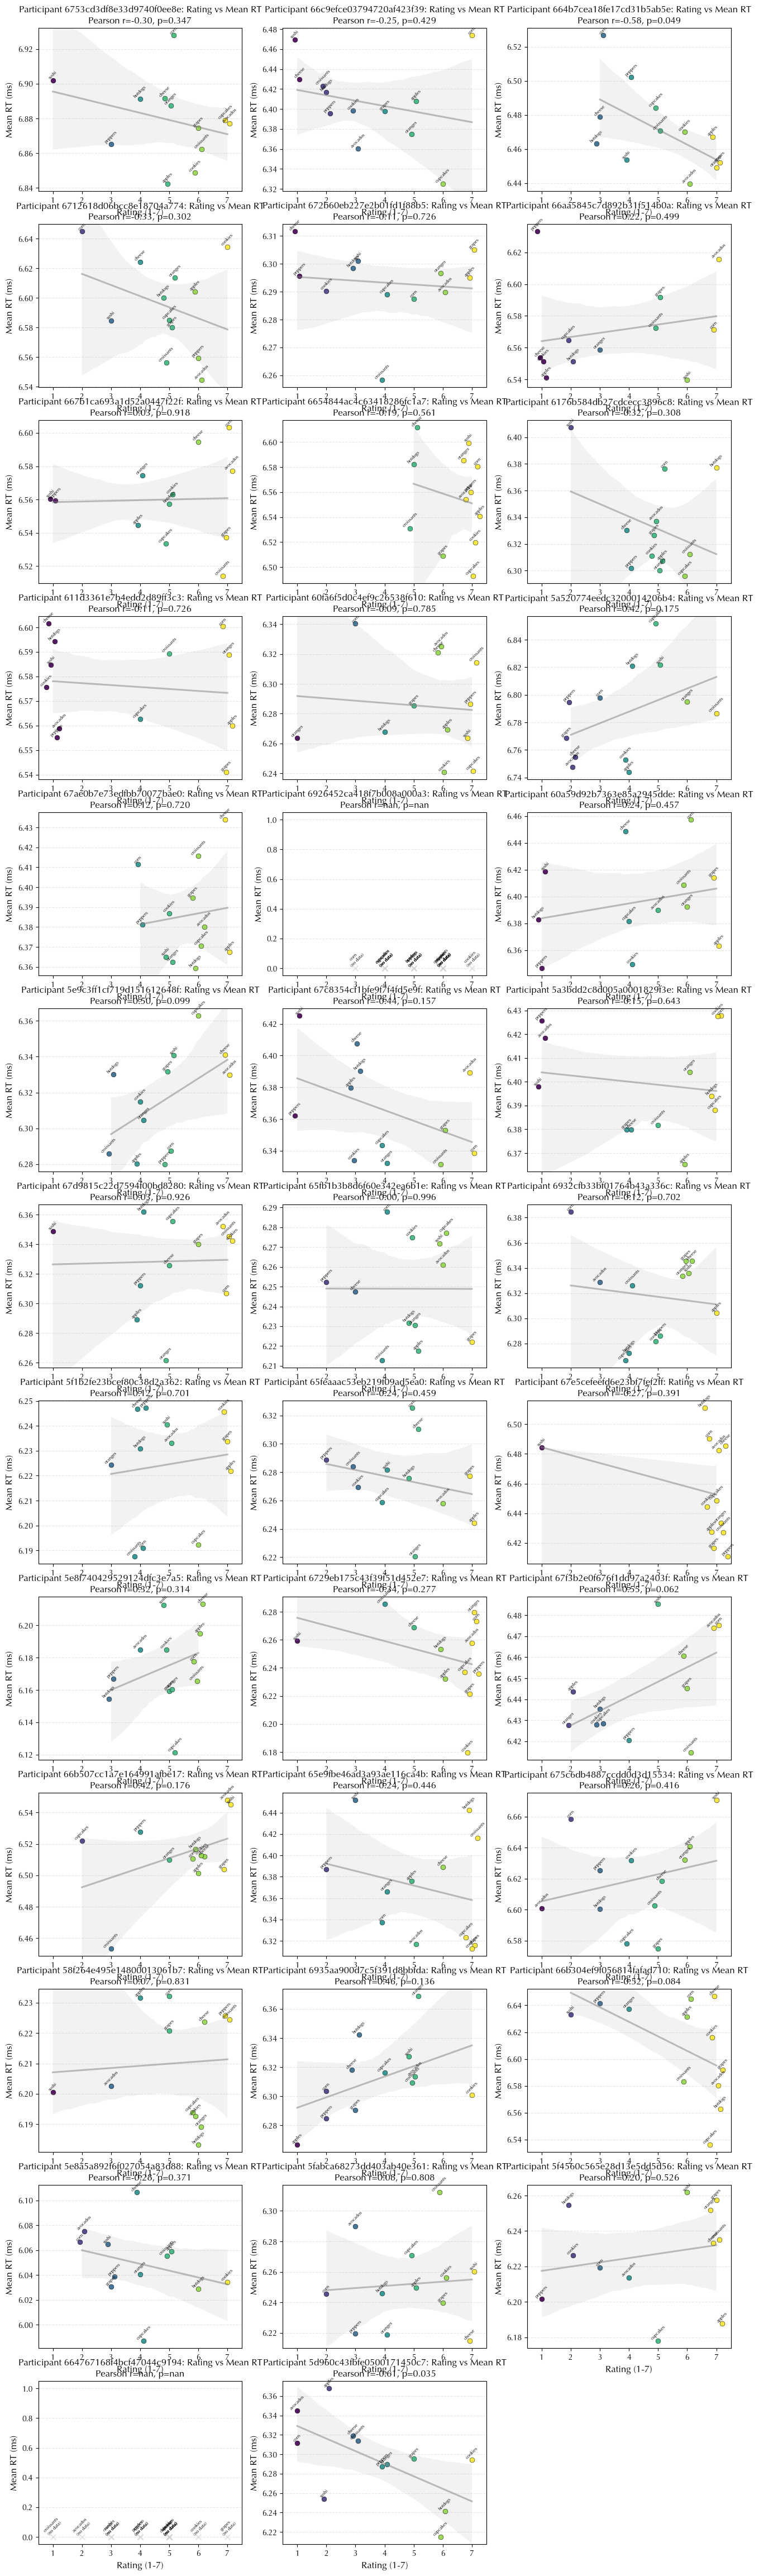

✓ Created rating-RT correlation plots for 38 participants


In [ ]:
# Correlate ratings with average RT per food item (per participant) with viridis color by rating (1=deep purple, 7=yellow)
from scipy.stats import pearsonr
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure food_names defined
food_names = [
    'apples', 'grapes', 'oranges', 'cheese', 'hotdogs', 'sushi',
    'corn', 'avocados', 'peppers', 'cookies', 'croissants', 'cupcakes'
]

# Viridis colormap scaled to ratings 1–7 (use modern colormap API to avoid deprecation warnings)
cmap = plt.colormaps.get_cmap('viridis')
norm = mcolors.Normalize(vmin=1, vmax=7)

def rank_and_offsets(food_indices, comparison_wins):
    n_items = len(food_indices)
    if n_items == 1:
        return food_indices, [0.0]

    # win counts within this rating group
    win_counts = {}
    for fidx in food_indices:
        wins = 0
        for other in food_indices:
            if fidx == other:
                continue
            if (fidx, other) in comparison_wins and comparison_wins[(fidx, other)] == fidx:
                wins += 1
        win_counts[fidx] = wins

    unique_wins = set(win_counts.values())
    has_comparisons = any((food_indices[i], food_indices[j]) in comparison_wins
                          for i in range(len(food_indices))
                          for j in range(i + 1, len(food_indices)))
    is_circular = len(unique_wins) == 1 and n_items > 1

    if (not has_comparisons) or is_circular:
        ranked = food_indices
        offsets = [0.0] * n_items
    else:
        ranked = sorted(food_indices, key=lambda x: win_counts[x], reverse=True)
        if n_items == 2:
            offsets = [-0.08, 0.08]
        elif n_items == 3:
            offsets = [-0.12, 0.0, 0.12]
        elif n_items == 4:
            offsets = [-0.16, -0.05, 0.05, 0.16]
        elif n_items == 5:
            offsets = [-0.20, -0.10, 0.0, 0.10, 0.20]
        elif n_items == 6:
            offsets = [-0.22, -0.14, -0.06, 0.06, 0.14, 0.22]
        elif n_items == 7:
            offsets = [-0.24, -0.16, -0.08, 0.0, 0.08, 0.16, 0.24]
        else:
            step = 0.08
            offsets = [(i - (n_items - 1) / 2) * step for i in range(n_items)]
    return ranked, offsets

# Collect all scatter plot data first
all_scatter_data = []

for pid in df_posttest['id'].unique():
    participant_data = df_posttest[df_posttest['id'] == pid]
    if len(participant_data) == 0:
        continue

    # Parse ratings
    ratings_raw = participant_data['ratings'].iloc[0]
    if isinstance(ratings_raw, str):
        ratings = literal_eval(ratings_raw.replace(', ', ',').replace(' ', ''))
    elif isinstance(ratings_raw, list):
        ratings = ratings_raw
    else:
        ratings = list(ratings_raw)

    if len(ratings) != len(food_names):
        print(f"Skipping {pid}: unexpected ratings length {len(ratings)}")
        continue

    # Build comparison matrix from pairwise comparisons
    comparison_rows = participant_data[['left_stim', 'right_stim', 'response']]
    comparison_wins = {}
    for _, row in comparison_rows.iterrows():
        left_name = row['left_stim']; right_name = row['right_stim']
        if left_name in food_names and right_name in food_names:
            left_idx = food_names.index(left_name)
            right_idx = food_names.index(right_name)
            if row['response'] == 'left':
                winner = left_idx
            elif row['response'] == 'right':
                winner = right_idx
            else:
                continue
            comparison_wins[(left_idx, right_idx)] = winner
            comparison_wins[(right_idx, left_idx)] = winner

    # Compute average RT per food for this participant
    df_pid = df[df['id'] == pid]
    base_ratings = []
    rt_means = []
    labels = []
    for idx, food in enumerate(food_names):
        rating_val = float(ratings[idx])
        trials = df_pid[(df_pid['distractor_id'] == food) & (df_pid['RT_filter'] == True) & (df_pid['correct'] == 1)]
        avg_rt = trials['logRT'].mean() if len(trials) > 0 else None
        base_ratings.append(rating_val)
        rt_means.append(avg_rt)
        labels.append(food)

    # Group by rating and assign offsets
    rating_groups = {}
    for idx, rating_val in enumerate(base_ratings):
        rating_groups.setdefault(rating_val, []).append(idx)

    x_positions = [None] * len(food_names)
    for rating_val, food_idxs in rating_groups.items():
        ranked, offsets = rank_and_offsets(food_idxs, comparison_wins)
        for rank_idx, food_idx in enumerate(ranked):
            x_positions[food_idx] = rating_val + offsets[rank_idx]

    # Pearson correlation on base ratings vs RT (excluding missing RT)
    valid_pairs = [(r, rt) for r, rt in zip(base_ratings, rt_means) if rt is not None]
    if len(valid_pairs) >= 2:
        xs, ys = zip(*valid_pairs)
        r_val, p_val = pearsonr(xs, ys)
    else:
        r_val, p_val = float('nan'), float('nan')

    # Store scatter plot data
    all_scatter_data.append({
        'pid': pid,
        'x_positions': x_positions,
        'rt_means': rt_means,
        'labels': labels,
        'base_ratings': base_ratings,
        'valid_pairs': valid_pairs,
        'r_val': r_val,
        'p_val': p_val
    })

# Create grid figure with 3 columns
n_participants = len(all_scatter_data)
n_cols = 3
n_rows = int(np.ceil(n_participants / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.5 * n_rows))
axes = axes.flatten() if n_participants > 1 else [axes]

for idx, sdata in enumerate(all_scatter_data):
    ax = axes[idx]
    pid = sdata['pid']
    x_positions = sdata['x_positions']
    rt_means = sdata['rt_means']
    labels = sdata['labels']
    base_ratings = sdata['base_ratings']
    valid_pairs = sdata['valid_pairs']
    r_val = sdata['r_val']
    p_val = sdata['p_val']

    # Background regression line + CI (no scatter) plotted first
    if len(valid_pairs) >= 2:
        xs_array, ys_array = zip(*valid_pairs)
        xs_array = list(xs_array)
        ys_array = list(ys_array)
        sns.regplot(x=xs_array, y=ys_array, scatter=False, ci=95, ax=ax,
                    color='gray', line_kws={'alpha': 0.5})
        
        # CI is the first PolyCollection in ax.collections
        if ax.collections:
            ax.collections[0].set_alpha(0.1)

    # Scatter points with displacement and labels
    for x_val, y_val, label, rating_val in zip(x_positions, rt_means, labels, base_ratings):
        color = cmap(norm(rating_val))
        if y_val is None:
            ax.scatter(x_val, 0, color='lightgray', alpha=0.6, marker='x', s=50)
            ax.text(x_val, 0, f"{label}\n(no data)", ha='center', va='bottom', fontsize=6, rotation=45)
        else:
            ax.scatter(x_val, y_val, color=color, alpha=0.9, edgecolor='black', linewidth=0.4, s=40)
            ax.text(x_val, y_val, label, ha='center', va='bottom', fontsize=6, rotation=45)

    ax.set_xlabel('Rating (1-7)')
    ax.set_ylabel('Mean RT (ms)')
    ax.set_title(f'Participant {pid}: Rating vs Mean RT\nPearson r={r_val:.2f}, p={p_val:.3f}')
    ax.set_xlim(0.5, 7.5)
    ymin = min([y for y in rt_means if y is not None], default=0)
    ymax = max([y for y in rt_means if y is not None], default=1)
    if ymin == ymax:
        ymin, ymax = 0, 1
    pad = 0.05 * (ymax - ymin)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

# Hide extra subplots if any
for idx in range(n_participants, len(axes)):
    axes[idx].axis('off')

# Display and save AFTER all subplots are created
fig.savefig(os.path.join(download_folder, 'all_participants_rating_rt.png'), bbox_inches='tight', dpi=150)
plt.show()

print(f"✓ Created rating-RT correlation plots for {n_participants} participants")

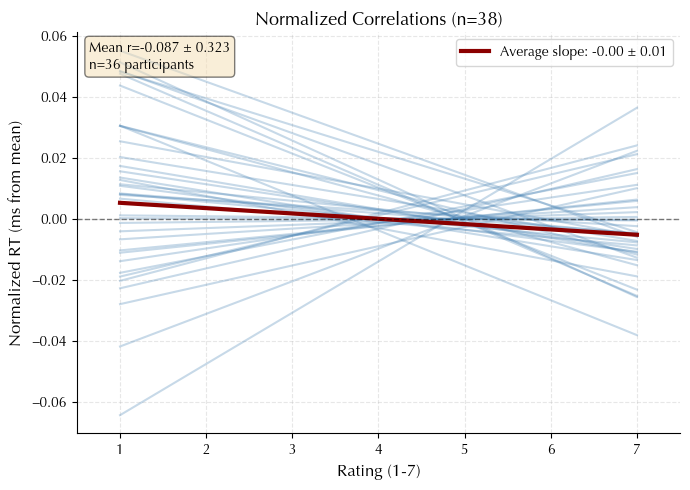

✓ Created normalized correlation summary
  Average slope: -0.00 ± 0.01 ms/rating
  Mean correlation: r=-0.087 ± 0.323


In [ ]:
# Correlate ratings with average RT per food item (per participant) with viridis color by rating (1=deep purple, 7=yellow)
from scipy.stats import pearsonr
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure food_names defined
food_names = [
    'apples', 'grapes', 'oranges', 'cheese', 'hotdogs', 'sushi',
    'corn', 'avocados', 'peppers', 'cookies', 'croissants', 'cupcakes'
]

# Viridis colormap scaled to ratings 1–7 (use modern colormap API to avoid deprecation warnings)
cmap = plt.colormaps.get_cmap('viridis')
norm = mcolors.Normalize(vmin=1, vmax=7)

def rank_and_offsets(food_indices, comparison_wins):
    n_items = len(food_indices)
    if n_items == 1:
        return food_indices, [0.0]

    # win counts within this rating group
    win_counts = {}
    for fidx in food_indices:
        wins = 0
        for other in food_indices:
            if fidx == other:
                continue
            if (fidx, other) in comparison_wins and comparison_wins[(fidx, other)] == fidx:
                wins += 1
        win_counts[fidx] = wins

    unique_wins = set(win_counts.values())
    has_comparisons = any((food_indices[i], food_indices[j]) in comparison_wins
                          for i in range(len(food_indices))
                          for j in range(i + 1, len(food_indices)))
    is_circular = len(unique_wins) == 1 and n_items > 1

    if (not has_comparisons) or is_circular:
        ranked = food_indices
        offsets = [0.0] * n_items
    else:
        ranked = sorted(food_indices, key=lambda x: win_counts[x], reverse=True)
        if n_items == 2:
            offsets = [-0.08, 0.08]
        elif n_items == 3:
            offsets = [-0.12, 0.0, 0.12]
        elif n_items == 4:
            offsets = [-0.16, -0.05, 0.05, 0.16]
        elif n_items == 5:
            offsets = [-0.20, -0.10, 0.0, 0.10, 0.20]
        elif n_items == 6:
            offsets = [-0.22, -0.14, -0.06, 0.06, 0.14, 0.22]
        elif n_items == 7:
            offsets = [-0.24, -0.16, -0.08, 0.0, 0.08, 0.16, 0.24]
        else:
            step = 0.08
            offsets = [(i - (n_items - 1) / 2) * step for i in range(n_items)]
    return ranked, offsets

# Collect all scatter plot data first
all_scatter_data = []

for pid in df_posttest['id'].unique():
    participant_data = df_posttest[df_posttest['id'] == pid]
    if len(participant_data) == 0:
        continue

    # Parse ratings
    ratings_raw = participant_data['ratings'].iloc[0]
    if isinstance(ratings_raw, str):
        ratings = literal_eval(ratings_raw.replace(', ', ',').replace(' ', ''))
    elif isinstance(ratings_raw, list):
        ratings = ratings_raw
    else:
        ratings = list(ratings_raw)

    if len(ratings) != len(food_names):
        print(f"Skipping {pid}: unexpected ratings length {len(ratings)}")
        continue

    # Build comparison matrix from pairwise comparisons
    comparison_rows = participant_data[['left_stim', 'right_stim', 'response']]
    comparison_wins = {}
    for _, row in comparison_rows.iterrows():
        left_name = row['left_stim']; right_name = row['right_stim']
        if left_name in food_names and right_name in food_names:
            left_idx = food_names.index(left_name)
            right_idx = food_names.index(right_name)
            if row['response'] == 'left':
                winner = left_idx
            elif row['response'] == 'right':
                winner = right_idx
            else:
                continue
            comparison_wins[(left_idx, right_idx)] = winner
            comparison_wins[(right_idx, left_idx)] = winner

    # Compute average RT per food for this participant
    df_pid = df[df['id'] == pid]
    base_ratings = []
    rt_means = []
    labels = []
    for idx, food in enumerate(food_names):
        rating_val = float(ratings[idx])
        trials = df_pid[(df_pid['distractor_id'] == food) & (df_pid['RT_filter'] == True) & (df_pid['correct'] == 1) & (df_pid['dist'] == 'real')]
        avg_rt = trials['logRT'].mean() if len(trials) > 0 else None
        base_ratings.append(rating_val)
        rt_means.append(avg_rt)
        labels.append(food)

    # Group by rating and assign offsets
    rating_groups = {}
    for idx, rating_val in enumerate(base_ratings):
        rating_groups.setdefault(rating_val, []).append(idx)

    x_positions = [None] * len(food_names)
    for rating_val, food_idxs in rating_groups.items():
        ranked, offsets = rank_and_offsets(food_idxs, comparison_wins)
        for rank_idx, food_idx in enumerate(ranked):
            x_positions[food_idx] = rating_val + offsets[rank_idx]

    # Pearson correlation on base ratings vs RT (excluding missing RT)
    valid_pairs = [(r, rt) for r, rt in zip(base_ratings, rt_means) if rt is not None]
    if len(valid_pairs) >= 2:
        xs, ys = zip(*valid_pairs)
        r_val, p_val = pearsonr(xs, ys)
    else:
        r_val, p_val = float('nan'), float('nan')

    # Store scatter plot data
    all_scatter_data.append({
        'pid': pid,
        'x_positions': x_positions,
        'rt_means': rt_means,
        'labels': labels,
        'base_ratings': base_ratings,
        'valid_pairs': valid_pairs,
        'r_val': r_val,
        'p_val': p_val
    })

# Single summary figure: individual normalized lines + average line
fig, ax1 = plt.subplots(1, 1, figsize=(7, 5))

all_slopes = []
all_normalized_data = []

for sdata in all_scatter_data:
    valid_pairs = sdata['valid_pairs']
    if len(valid_pairs) >= 2:
        xs, ys = zip(*valid_pairs)
        xs_array = np.array(xs)
        ys_array = np.array(ys)

        # Fit linear regression to get slope and intercept
        slope, intercept = np.polyfit(xs_array, ys_array, 1)
        all_slopes.append(slope)

        # Normalize: subtract mean RT to center around 0 (removes intercept variation)
        mean_rt = np.mean(ys_array)
        ys_normalized = ys_array - mean_rt

        all_normalized_data.append({
            'xs': xs_array,
            'ys_normalized': ys_normalized,
            'slope': slope
        })

# Plot individual normalized regression lines
for pdata in all_normalized_data:
    xs = pdata['xs']
    ys_norm = pdata['ys_normalized']
    slope_norm, intercept_norm = np.polyfit(xs, ys_norm, 1)
    x_line = np.linspace(1, 7, 100)
    y_line = slope_norm * x_line + intercept_norm
    ax1.plot(x_line, y_line, alpha=0.3, linewidth=1.5, color='steelblue')

# Add averaged regression line in red
if all_slopes:
    avg_slope = np.mean(all_slopes)
    std_slope = np.std(all_slopes)
    x_line = np.linspace(1, 7, 100)
    x_center = 4  # Center of rating scale (1-7)
    y_line_avg = avg_slope * (x_line - x_center)
    ax1.plot(x_line, y_line_avg, linewidth=3, color='darkred', label=f'Average slope: {avg_slope:.2f} ± {std_slope:.2f}')

    all_r_values = [sdata['r_val'] for sdata in all_scatter_data if not np.isnan(sdata['r_val'])]
    mean_r = np.mean(all_r_values) if all_r_values else np.nan
    std_r = np.std(all_r_values) if all_r_values else np.nan
    ax1.text(0.02, 0.98, f'Mean r={mean_r:.3f} ± {std_r:.3f}\nn={len(all_r_values)} participants',
            transform=ax1.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax1.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_xlabel('Rating (1-7)', fontsize=12)
ax1.set_ylabel('Normalized RT (ms from mean)', fontsize=12)
ax1.set_title(f'Normalized Correlations (n={len(all_scatter_data)})', fontsize=13, fontweight='bold')
ax1.set_xlim(0.5, 7.5)
ax1.grid(axis='both', linestyle='--', alpha=0.3)
ax1.legend(loc='best', fontsize=10)
sns.despine(ax=ax1)

plt.tight_layout()
fig.savefig(os.path.join(download_folder, 'correlation_summary_normalized.png'), bbox_inches='tight', dpi=150)
plt.show()

print(f"✓ Created normalized correlation summary")
if all_slopes:
    print(f"  Average slope: {avg_slope:.2f} ± {std_slope:.2f} ms/rating")
    print(f"  Mean correlation: r={mean_r:.3f} ± {std_r:.3f}")
